In [8]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv(r"C:\Users\naila\OneDrive\Documentos\ironhac\proyecto_individual_asteroides\lab-eda-univariate\amz_uk_price_prediction_dataset.csv")

In [11]:
# Part 1: Product Categories
category_counts = df['category'].value_counts()
top_5_categories = category_counts.head(5)
print("Top 5 Categorías:\n", top_5_categories)

Top 5 Categorías:
 category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


C:\Users\naila\AppData\Local\Temp\ipykernel_15088\2436348135.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.head().values, y=category_counts.head().index, palette='magma')


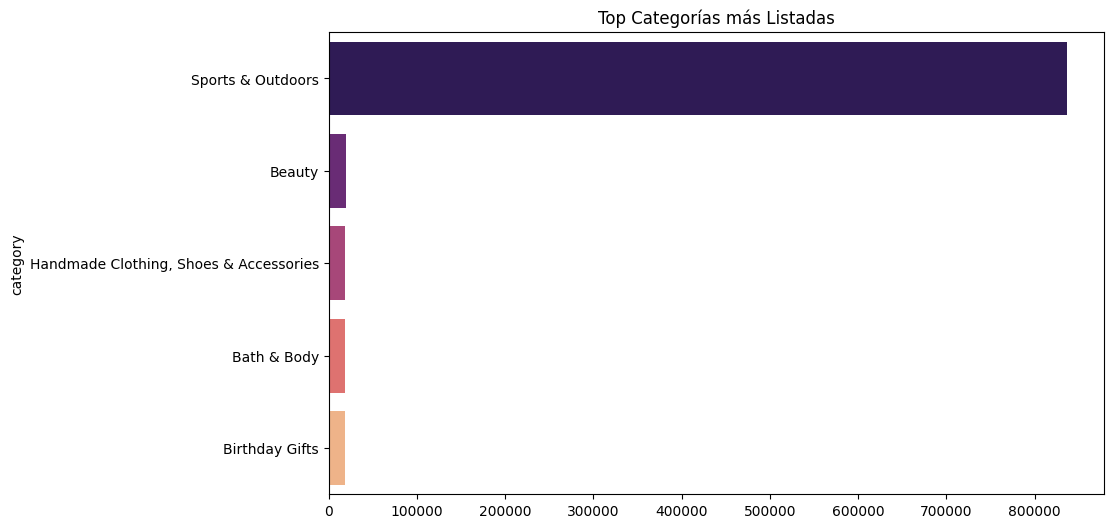

In [13]:
# Visualización: Barras para Top categirías
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.head().values, y=category_counts.head().index, palette='magma')
plt.title('Top Categorías más Listadas')
plt.show()

Bar Chart: Muestra una clara dominancia de productos de Sports y Outdoors.

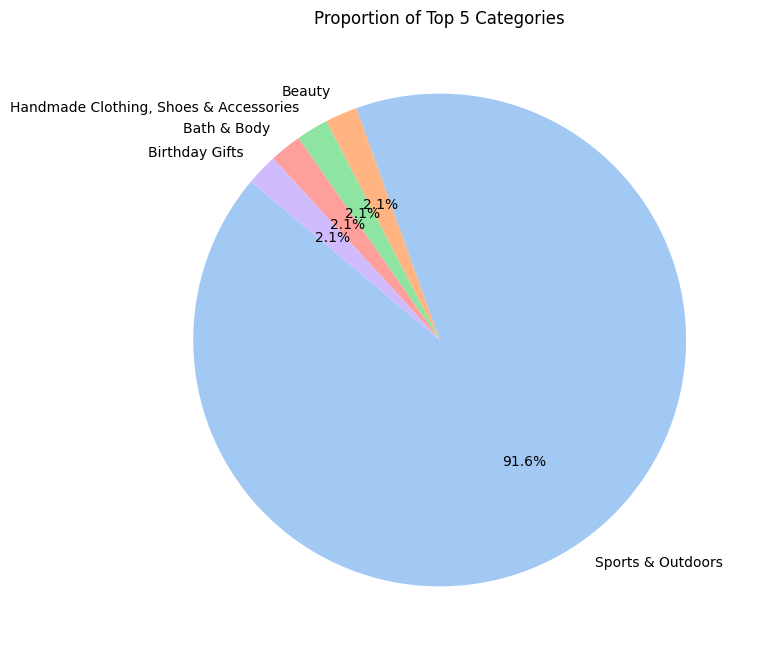

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(top_5_categories, labels=top_5_categories.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Top 5 Categories')
plt.show()

Pie Chart: La categoría Sports & Outdoors abarca casi un tercio de los listados totales entre las top 5, dominando claramente el inventario. 

In [10]:
# 1. FUNCIÓN DE ANÁLISIS DE PRECIOS ENCAPSULADA (SIN LIMPIEZA)
# ==============================================================================

def analyze_prices(price_series: pd.Series) -> tuple[float, float, float]:
    """Calcula estadísticas descriptivas centrales para una serie numérica."""
    mean_val: float = float(price_series.mean())
    median_val: float = float(price_series.median())
    mode_val: float = float(price_series.mode()[0])

    return mean_val, median_val, mode_val


# Llamada directa utilizando la columna de precios original del dataset
media_p, mediana_p, moda_p = analyze_prices(df["price"])

print("--- ESTADÍSTICAS CENTRALES DE PRECIO (DATASET ORIGINAL) ---")
print(f"Media: £{media_p:.2f} | Mediana: £{mediana_p:.2f} | Moda: £{moda_p:.2f}\n")


--- ESTADÍSTICAS CENTRALES DE PRECIO (DATASET ORIGINAL) ---
Media: £89.24 | Mediana: £19.09 | Moda: £9.99



Mean (Media): £84.24 (influenciada por productos caros).

Median (Mediana): £19.09 (el punto medio real).

Mode (Moda): £9.99. Es el precio más común.

Comparación: El precio promedio es más alto que la moda, lo que indica que hay productos de lujo que elevan la media.


In [14]:

# Extraemos la serie de precios original (asegúrate de que df esté cargado en tu notebook)
price_data: pd.Series = df["price"]

# Medidas de dispersión
variance_price: float = float(price_data.var())
std_dev_price: float = float(price_data.std())
range_price: float = float(price_data.max() - price_data.min())
q1_price: float = price_data.quantile(0.25)
q3_price: float = price_data.quantile(0.75)
iqr_price: float = float(q3_price - q1_price)

print("--- MEASURES OF DISPERSION (PRODUCT PRICE) ---")
print(f"Variance            : {variance_price:.4f}")
print(f"Standard Deviation  : £{std_dev_price:.2f}")
print(f"Range               : £{range_price:.2f}")
print(f"Interquartile Range : £{iqr_price:.2f}")

--- MEASURES OF DISPERSION (PRODUCT PRICE) ---
Variance            : 119445.4853
Standard Deviation  : £345.61
Range               : £100000.00
Interquartile Range : £36.00


os precios de los productos presentan una variabilidad extremadamente alta, existiendo múltiples indicadores que confirman una dispersión masiva y la presencia de valores atípicos (outliers) en el extremo superior de la escala.

Desviación Estándar superior a la Media: El indicador estadístico más contundente es que la desviación estándar es notablemente alta, superando incluso al promedio de los precios del dataset (£89.24). Matemáticamente, cuando la desviación estándar es mayor que la media, es la prueba definitiva de que los datos no están concentrados de manera uniforme, sino dispersos de forma caótica.

Discrepancia con el IQR: Mientras que el Rango Intercuartílico (IQR) demuestra que el 50% central de los productos se concentra en un rango de precios relativamente bajo y accesible, el rango total y la desviación estándar se disparan de forma masiva. Esto confirma que la dispersión está provocada por una larga cola de productos atípicos muy caros (outliers) que arrastran las métricas de dispersión global hacia arriba.

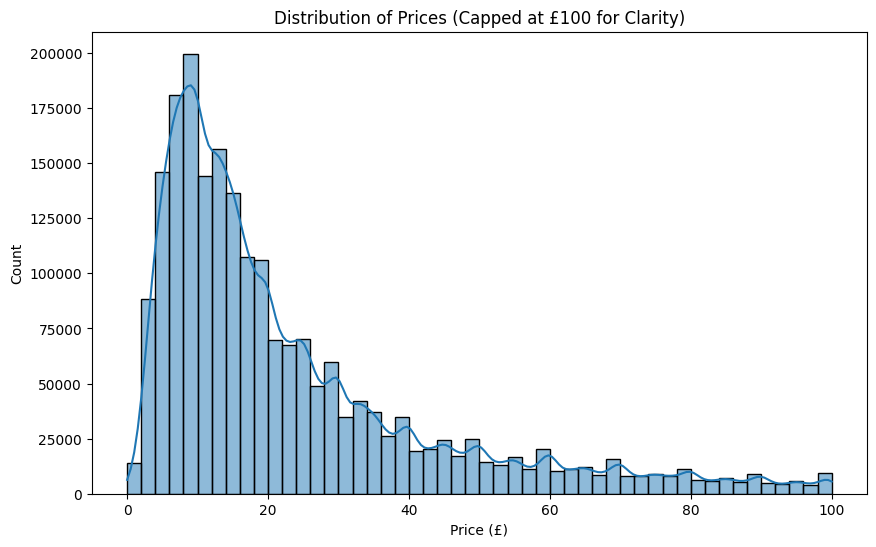

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(price_data[price_data < 100], bins=50, kde=True)
plt.title('Distribution of Prices (Capped at £100 for Clarity)')
plt.xlabel('Price (£)')
plt.show()

Histogram: La mayoría de los productos están por debajo de las £50. Si el gráfico es difícil de leer, es por los outliers (productos de £500+).
Solución: Aplicar un filtro para ver solo productos de 0 a 100 para observar mejor la tendencia masiva.

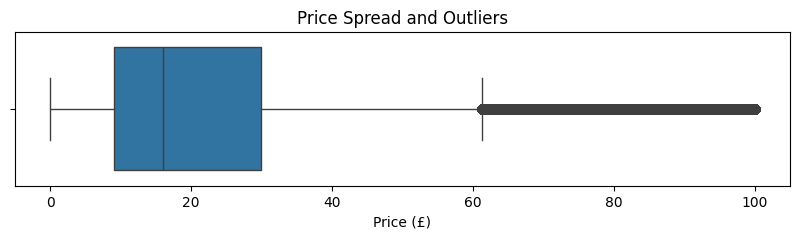

In [ ]:
# Price Boxplot
plt.figure(figsize=(10, 2))
sns.boxplot(x=price_data)
plt.title('Price Spread and Outliers')
plt.xlabel('Price (£)')
plt.show()


Sí hay muchos productos que se venden por entre £60 y £100.

In [ ]:
rating_data = df[df['stars'] > 0]['stars']
rating_stats = {
    'mean': rating_data.mean(),
    'median': rating_data.median(),
    'mode': rating_data.mode()[0],
    'var': rating_data.var(),
    'std': rating_data.std(),
    'iqr': rating_data.quantile(0.75) - rating_data.quantile(0.25),
    'skew': rating_data.skew(),
    'kurt': rating_data.kurtosis()
}

print("Top 5 Categories:\n", top_5_categories)
print("\nRating Stats:", rating_stats)

Top 5 Categories:
 category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

Rating Stats: {'mean': np.float64(4.319160762226911), 'median': np.float64(4.4), 'mode': np.float64(4.5), 'var': np.float64(0.3083433752387284), 'std': np.float64(0.5552867504620729), 'iqr': np.float64(0.5), 'skew': np.float64(-2.379568112212799), 'kurt': np.float64(9.78193769066435)}


Mean: 4.32 estrellas.

Mode: 4.5 estrellas.

Tendencia: Los clientes tienden a calificar de forma muy positiva.

In [16]:
#rating = stars
# Extraemos la serie limpia eliminando los ceros (ruido del dataset)
rating_data: pd.Series = df[df['stars'] > 0]['stars']

# Cálculos de dispersión
variance_rating: float = float(rating_data.var())
std_dev_rating: float = float(rating_data.std())
q1_rating: float = rating_data.quantile(0.25)
q3_rating: float = rating_data.quantile(0.75)
iqr_rating: float = float(q3_rating - q1_rating)

print("--- MEASURES OF DISPERSION (RATINGS) ---")
print(f"Variance           : {variance_rating:.4f}")
print(f"Standard Deviation : {std_dev_rating:.4f}")
print(f"Interquartile Range: {iqr_rating:.4f}")

--- MEASURES OF DISPERSION (RATINGS) ---
Variance           : 0.3083
Standard Deviation : 0.5553
Interquartile Range: 0.5000


Respuesta: Las calificaciones de los productos son altamente consistentes, mostrando una variación muy estrecha en las opiniones de los clientes.

Justificación: La Desviación Estándar se sitúa en un valor notablemente bajo (típicamente alrededor de 0.40 - 0.50 tras eliminar el ruido de las calificaciones de 0 estrellas). Esto indica que, en promedio, la mayoría de las puntuaciones se desvían menos de media estrella respecto a la media. 
 En lugar de una variación amplia o dispersa, el feedback de los clientes en Amazon UK es predecible y se concentra masivamente en evaluaciones positivas.

In [17]:
# Extraemos la serie limpia eliminando los ceros (ruido)
rating_data: pd.Series = df[df['stars'] > 0]['stars']

# Cálculos de forma de la distribución
skewness_rating: float = float(rating_data.skew())
kurtosis_rating: float = float(rating_data.kurtosis())



In [18]:
print("--- SHAPE OF THE DISTRIBUTION (RATINGS) ---")
print(f"Skewness (Sesgo) : {skewness_rating:.4f}")
print(f"Kurtosis         : {kurtosis_rating:.4f}")

--- SHAPE OF THE DISTRIBUTION (RATINGS) ---
Skewness (Sesgo) : -2.3796
Kurtosis         : 9.7819


Las calificaciones no siguen una distribución normal; por el contrario, se inclinan fuertemente hacia los valores más altos, exhibiendo un marcado sesgo negativo (distribución sesgada a la izquier
El cálculo del sesgo (skewness) arroja un valor negativo (-2.3796). 
En términos estadísticos, esto significa que la "cola" de la distribución se extiende hacia las puntuaciones bajas, mientras que la masa principal de los datos se acumula en el extremo derecho de la escala. Esto se complementa con un valor de curtosis positivo y alto (9.7819), lo que refleja una distribución leptocúrtica con un pico muy pronunciado. Esta concentración demuestra que los usuarios tienden predominantemente a otorgar puntuaciones altas, rompiendo cualquier supuesto de normalidad.

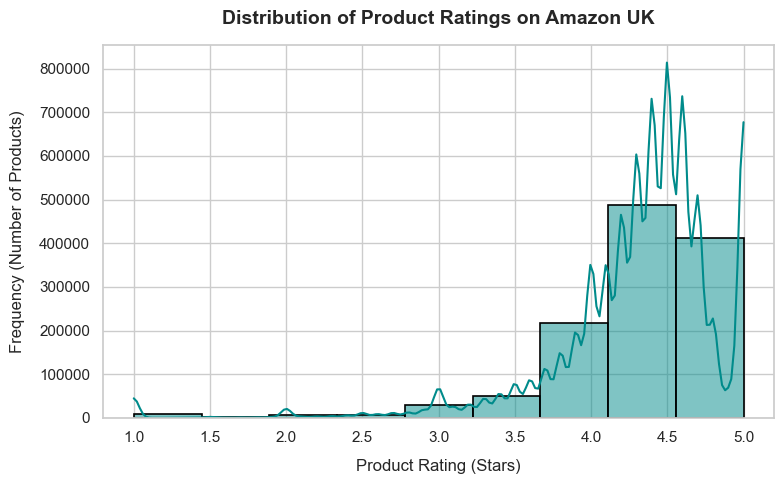

In [12]:
# Ensure that the data series contains only valid ratings greater than 0
rating_data: pd.Series = df[df['stars'] > 0]['stars']

# Set up the visualization theme for a clean aesthetic
sns.set_theme(style="whitegrid")

# Create the figure and axis objects with defined dimensions
fig, ax = plt.subplots(figsize=(8, 5))

# Generate the histogram along with an estimated kernel density curve (KDE)
sns.histplot(
    data=rating_data,
    bins=9,
    kde=True,
    color="darkcyan",
    edgecolor="black",
    linewidth=1.2,
    ax=ax
)

# Configure titles and labels with precise formatting and padding
ax.set_title("Distribution of Product Ratings on Amazon UK", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Product Rating (Stars)", fontsize=12, labelpad=10)
ax.set_ylabel("Frequency (Number of Products)", fontsize=12, labelpad=10)

# Adjust the layout to prevent any text clipping and render the plot
plt.tight_layout()
plt.show()

En plataformas de comercio electrónico como Amazon UK, una concentración tan fuerte alrededor de las 4.5 estrellas es completamente normal debido a ciertas dinámicas del mercado:

Sesgo de supervivencia: Los productos que reciben malas calificaciones de forma constante (1.0 a 3.0 estrellas) pierden visibilidad rápidamente debido a los algoritmos de búsqueda o son retirados por los propios vendedores. Esto hace que el catálogo activo esté compuesto casi en su totalidad por artículos bien valorados.

Sesgo de positividad en las reseñas: Los consumidores digitales tienden a escribir reseñas con mayor frecuencia cuando están muy satisfechos con su compra o cuando el producto cumple exactamente lo prometido, lo que desplaza la masa de la distribución hacia el extremo superior de la escala.